# Overfitting minimal set of intervals

## imports

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

PAL_MODALITIES = {
    "rna_seq": "#717EC3",
    "splice_site": "#AE8799",
    "splice_usage": "#C95D63",
    "splice_junctions": "#EE8434"
}

MAP_MODALITIES = {
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions"
}

OUTPUT_DIR = os.path.join("pdfs","overfitting_dev")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## data

In [2]:
# paths

ROOT = ".."
OUTPUT_DIR = os.path.join(ROOT,"results/bsc/finetuning/alphagenome_pytorch/overfitting/dev")
logs_file = os.path.join(OUTPUT_DIR, "summary", "epoch_logs.parquet")

In [3]:
# loads

logs = pd.read_parquet(logs_file)

## figures

In [4]:
logs.value_counts(["run_name"])

run_name                                                                  
debug_splice_junctions__randinit__newloss__predicted__frozen__singlegpu       50
debug_splice_junctions__randinit__newloss__predicted__frozen__multigpu_sp     50
debug_splice_junctions__randinit__newloss__predicted__frozen__multigpu_ddp    50
Name: count, dtype: int64

### splice site and junction heads struggle to overfit a single interval

In [5]:
runs_oi = [
    "debug_splice_junctions__randinit__origloss__predicted__frozen",
    "debug_splice_junctions__pretrinit__origloss__predicted__frozen"
]
X = logs#.query("run_name.isin(@runs_oi)")

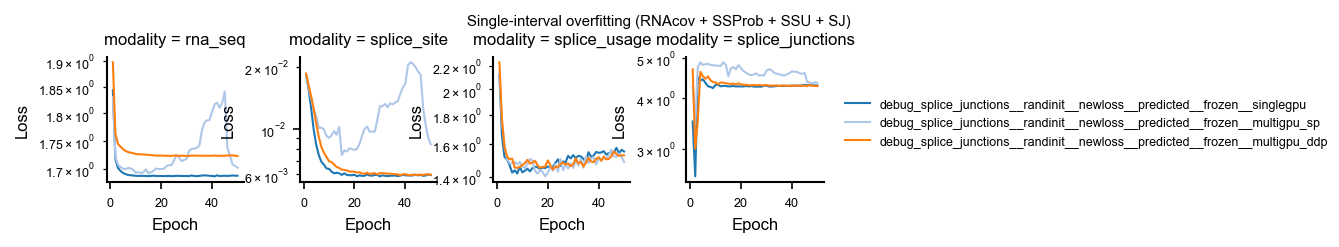

In [6]:
x = (
    X[
        ["epoch","run_name","val_loss_rna_seq_loss","val_loss_splice_site_loss","val_loss_splice_usage_loss","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name", palette="tab20",
    col="modality", col_order=PAL_MODALITIES.keys(),
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

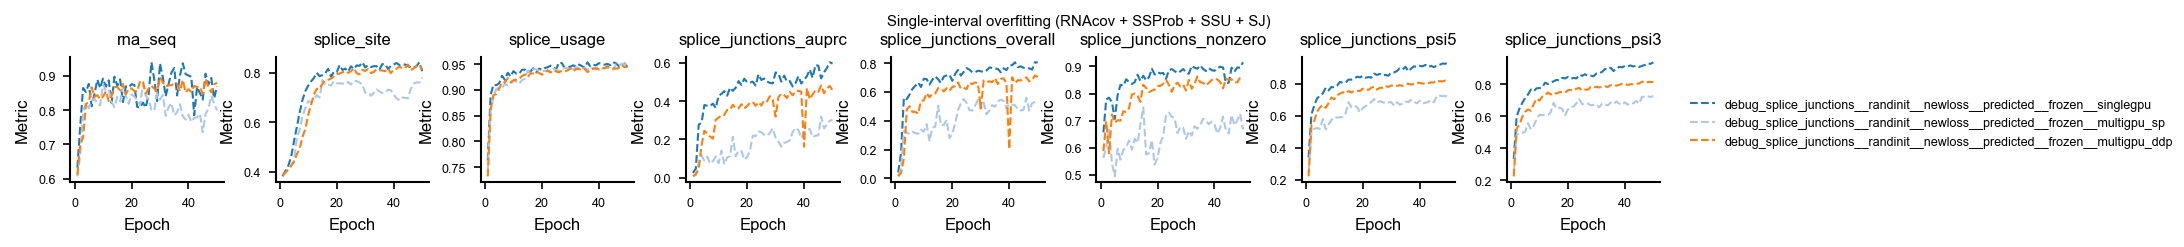

In [7]:
x = pd.concat([
    (
        X[
            ["epoch","run_name","train_rna_seq_1bp_profile_pearson_r_mean","train_splice_usage_pearson_r",
             "train_splice_junctions_auprc_junction","train_splice_junctions_pearson_r","train_splice_junctions_pearson_r_nonzero","train_splice_junctions_pearson_r_psi5","train_splice_junctions_pearson_r_psi3"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="correlation")
    ),
    (
        X[
            ["epoch","run_name","train_splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
mapping = {
    "train_rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "train_splice_site_auprc_macro":"splice_site",
    "train_splice_usage_pearson_r":"splice_usage",
    "train_splice_junctions_auprc_junction":"splice_junctions_auprc",
    "train_splice_junctions_pearson_r":"splice_junctions_overall",
    "train_splice_junctions_pearson_r_nonzero":"splice_junctions_nonzero",
    "train_splice_junctions_pearson_r_psi5":"splice_junctions_psi5",
    "train_splice_junctions_pearson_r_psi3":"splice_junctions_psi3",
}
x["modality"] = x["modality"].map(mapping)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name", palette="tab20",
    col="modality", col_order=mapping.values(),
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Metric"
)
g.set_titles("{col_name}")
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

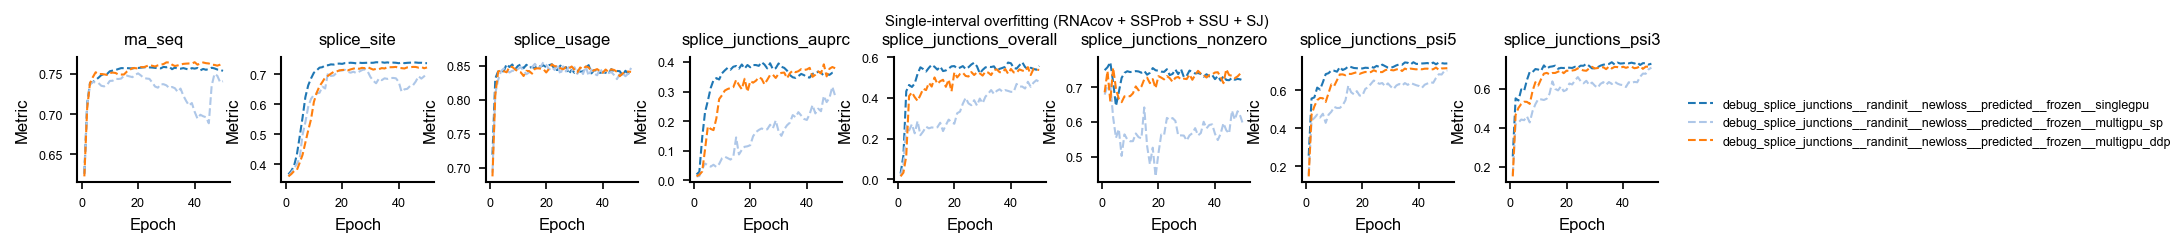

In [8]:
x = pd.concat([
    (
        X[
            ["epoch","run_name","rna_seq_1bp_profile_pearson_r_mean","splice_usage_pearson_r",
             "splice_junctions_auprc_junction","splice_junctions_pearson_r","splice_junctions_pearson_r_nonzero","splice_junctions_pearson_r_psi5","splice_junctions_pearson_r_psi3"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="correlation")
    ),
    (
        X[
            ["epoch","run_name","splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
mapping = {
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_auprc_junction":"splice_junctions_auprc",
    "splice_junctions_pearson_r":"splice_junctions_overall",
    "splice_junctions_pearson_r_nonzero":"splice_junctions_nonzero",
    "splice_junctions_pearson_r_psi5":"splice_junctions_psi5",
    "splice_junctions_pearson_r_psi3":"splice_junctions_psi3",
}
x["modality"] = x["modality"].map(mapping)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name", palette="tab20",
    col="modality", col_order=mapping.values(),
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Metric"
)
g.set_titles("{col_name}")
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()